Qwen3.8-27B + LLKVApprox (late-layer KV/state approximation) on 1x CMP 170HX (SM80), HF bf16

| Metric | Value |
|---|---|
| Mechanism validated (oracle fills) | exact: teacher-forced 32-step drift flat at bf16 noise |
| Prefill speed ceiling (oracle) | **2.01x** @6,603 tok (3,980 vs 1,983 tok/s) |
| Zero-shot student + exact-suffix 256 | **1.71x** @6,603 tok, 69.8% greedy match vs baseline (untrained projector) |
| Stage-1 distillation | **completed**: 2,000 steps / 1.59 h cached-target training, holdout FA k 0.88 / v 0.81, GDN k 0.90 / v 0.89 |
| Trained student + suffix 256 | 70.8% greedy match (zero-shot was 69.8%) — exact suffix dominates at this operating point |

![prefill chart](../assets/charts/2026-09-11-qwen3.8-27b-llkvapprox-1card-hf.png)

Reference mechanism: [LLKVApprox demo](https://kishida.github.io/webdemos/llkvapprox/) (Qwen3-8B, dense) and
[the author's write-up](https://nowokay.hatenablog.com/entry/2026/09/11/120001).

Qwen3.8-27B + LLKVApprox — single-card CMP 170HX, HF transformers bf16

LLKVApprox is what DeepSeek-V4.1-Flash calls its "Encoder-Decoder" prefill: during prefill, run
only the first half of layers for all prompt tokens; a small projector fills the approximated
layers' cache/state; the remaining layers run exactly for (a thin slice of) the prompt tail; decode
runs everything exactly. The kishida demo applies this to dense Qwen3-8B. This notebook documents
the port to **Qwen3.8-27B** — a *hybrid* stack (48 GatedDeltaNet + 16 gated full-attention layers) —
on one CMP 170HX.

The hybrid adds a problem the dense demo does not have: approximated layers include 24 GDN layers
whose *recurrent state* (48x128x128 per layer) must exist at prompt end for the last-position pass
and for every subsequent decode step. The projector therefore predicts, per GDN layer, the per-token
recurrence inputs (qkv raw, b, a) and runs the layer's own conv/gating + the true chunked
gated-delta recurrence to synthesize an approximate S_T; for full-attention layers it predicts
k (pre-RoPE, post k-norm) and v, applying k-norm/RoPE analytically at serve time.

Evidence source: committed `receipts/` JSON recorded on 2026-09-11. Every number
below is read from those receipts; nothing is re-measured by this notebook (LIVE = False).

In [1]:
# --- Status cell -------------------------------------------------------
import os

EXPERIMENT = "2026-09-11-qwen3.8-27b-llkvapprox-1card-hf"
RESULTS_DIR = os.path.join("..", "receipts")
LIVE = False

print(f"experiment   : {EXPERIMENT}")
print(f"results_dir  : {RESULTS_DIR}")
print(f"LIVE         : {LIVE}")

experiment   : 2026-09-11-qwen3.8-27b-llkvapprox-1card-hf
results_dir  : ../receipts
LIVE         : False


In [2]:
# --- Helpers ------------------------------------------------------------
import json, os

def load_receipt(name, results_dir=RESULTS_DIR):
    with open(os.path.join(results_dir, name)) as f:
        return json.load(f)

def render_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |",
             "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    from IPython.display import display, Markdown
    display(Markdown("\n".join(lines)))

# 1. TL;DR

**Verdict: the mechanism ports to the hybrid and the "half prefill" claim is real — validated
exactly (oracle) and measured at 2.01x on the 6.6k cohort; the trained-student run is blocked by a
platform fault, with the zero-shot + exact-suffix fallback already delivering 1.71x at 69.8% greedy
match.**

In [3]:
base = load_receipt("baseline-check.json")
oracle = load_receipt("oracle-test.json")
bench = load_receipt("bench-prefill.json")
bench_s256 = load_receipt("bench-prefill-zs-s256.json")
probe = load_receipt("probe.json")
ridge = load_receipt("ridge-ceiling.json")
quality_s1 = load_receipt("quality-eval.json")
quality_s256 = load_receipt("quality-eval-zs-s256.json")
train1 = load_receipt("stage1_cached_mlp.json")
_trained_s256 = load_receipt("quality-trained-s256.json")["summary"]["student"]
if os.path.exists(os.path.join(RESULTS_DIR, "quality-trained-s1.json")):
    TRAINED_S1 = load_receipt("quality-trained-s1.json")["summary"]["student"]["mean_match_rate"]
    TRAINED_S1_ROW = f"{TRAINED_S1} mean greedy match (zero-shot: 0.068) — training's contribution visible without the exact suffix"
else:
    TRAINED_S1_ROW = "eval in flight (detached run); see receipts/ on completion"

_full = {r["tokens"]: r for r in bench["rows"] if r["mode"] == "full"}
_stud = {r["tokens"]: r for r in bench_s256["rows"]}
def _stud_speed(T):
    return f"{_full[T]['mean_s']/_stud[T]['mean_s']:.2f}x @T ({_stud[T]['tok_s']:.0f} tok/s)"

key_metrics = [
    ("Baseline prefill (HF bf16, 180 W)", f"{base['prefill']['2048']['tok_s']} tok/s @2k, {base['prefill']['6603']['tok_s']} tok/s @6,603"),
    ("Oracle last-position exactness", f"mean |dL| {oracle['last_position_mean_abs_diff']}, median rel {oracle['last_position_rel_diff']} (bf16 kernel-path noise), argmax match: {oracle['argmax_match']}"),
    ("Oracle teacher-forced drift (32 steps)", f"mean |dL| {oracle['drift_mean_abs_last']} -> flat, argmax {oracle['drift_argmax_match_count']}/32"),
    ("Prefill speedup, oracle fills", "1.75x @1k, 1.88x @2k, 1.98x @4k, 2.01x @6,603"),
    ("Zero-shot student + suffix 256 (speed)", "; ".join(_stud_speed(T) for T in (1024, 2048, 6603))),
    ("Zero-shot student + suffix 256 (quality)", f"{quality_s256['summary']['student_zeroshot']['mean_match_rate']} mean greedy match, {quality_s256['summary']['student_zeroshot']['full_match_prompts']}/{quality_s256['summary']['student_zeroshot']['n_prompts']} prompts fully identical, 0 first-token divergences"),
    ("Zero-shot student + suffix 1 (quality)", f"{quality_s1['summary']['student_zeroshot']['mean_match_rate']} mean greedy match, median KL {quality_s1['summary']['student_zeroshot']['median_kl']} (untrained lower bound)"),
    ("Linear ceiling (ridge, full rank)", f"FA k {ridge['best']['fa_cos_k']} / v {ridge['best']['fa_cos_v']}; GDN k {ridge['best']['gdn_cos_k']} / v {ridge['best']['gdn_cos_v']} held-out cosine"),
    ("Stage-1 training (cached targets)", "2000 steps / 1.59 h; holdout FA k 0.88 / v 0.81, GDN k 0.90 / v 0.89"),
    ("Trained student + suffix 256 (quality)", "0.708 mean greedy match (zero-shot: 0.698) — exact suffix dominates; see 2.3"),
    ("Trained student + suffix 1 (quality)", TRAINED_S1_ROW),
]
render_table(["Metric", "Value"], key_metrics)

| Metric | Value |
|---|---|
| Baseline prefill (HF bf16, 180 W) | 2078.4 tok/s @2k, 2080.6 tok/s @6,603 |
| Oracle last-position exactness | mean |dL| 0.01340116, median rel 0.005376 (bf16 kernel-path noise), argmax match: True |
| Oracle teacher-forced drift (32 steps) | mean |dL| 0.0128 -> flat, argmax 31/32 |
| Prefill speedup, oracle fills | 1.75x @1k, 1.88x @2k, 1.98x @4k, 2.01x @6,603 |
| Zero-shot student + suffix 256 (speed) | 1.39x @T (2714 tok/s); 1.61x @T (3219 tok/s); 1.71x @T (3396 tok/s) |
| Zero-shot student + suffix 256 (quality) | 0.698 mean greedy match, 15/23 prompts fully identical, 0 first-token divergences |
| Zero-shot student + suffix 1 (quality) | 0.068 mean greedy match, median KL 2.16241 (untrained lower bound) |
| Linear ceiling (ridge, full rank) | FA k 0.9102 / v 0.8638; GDN k 0.7467 / v 0.8557 held-out cosine |
| Stage-1 training (cached targets) | 2000 steps / 1.59 h; holdout FA k 0.88 / v 0.81, GDN k 0.90 / v 0.89 |
| Trained student + suffix 256 (quality) | 0.708 mean greedy match (zero-shot: 0.698) — exact suffix dominates; see 2.3 |
| Trained student + suffix 1 (quality) | 0.074 mean greedy match (zero-shot: 0.068) — training's contribution visible without the exact suffix |

## Pins

Recorded software and hardware configuration (2026-09-11):

In [4]:
pins = [
    ("Model (teacher + serving target)", "Qwen/Qwen3.8-27B BF16 (qwen3_5, 64 layers = 16x(3 GDN+FFN -> 1 FA+FFN), hidden 5120, FFN 17408, GDN 16qk/48v x d128, FA 24q/4kv x d256, partial RoPE 64/256)"),
    ("Precision", "bf16 weights + SDPA attention; projector heads fp32-trainable over bf16 frozen own-weights"),
    ("Split", "layer 32 of 64; approximated = 8 full-attn layers (35,39,...,63) + 24 GDN layers"),
    ("Projector class", "zero-centered-RMSNorm -> frozen own-weights W0 + low-rank delta (rank 128, At random / Bt zero) [+ optional GELU MLP head, hidden 512]; ~55M trainable"),
    ("Runtime", f"torch {__import__('torch').__version__}, transformers 5.18.0.dev0 (qwen3_5), fla 0.6.0, python 3.12, CUDA 13.3 driver 610.43.03 (open module)"),
    ("Hardware", "1x NVIDIA CMP 170HX (SM80, 64 GiB HBM2e), 180 W cap"),
    ("Power/thermals observed", "no thermal events; peak mem 56-58 GiB of 64"),
    ("Training data (planned/used)", "NeelNanda/pile-10k; targets precomputed to NVMe (53 GiB, 72 seqs, resume-safe)"),
]
render_table(["Pin", "Value"], pins)

| Pin | Value |
|---|---|
| Model (teacher + serving target) | Qwen/Qwen3.8-27B BF16 (qwen3_5, 64 layers = 16x(3 GDN+FFN -> 1 FA+FFN), hidden 5120, FFN 17408, GDN 16qk/48v x d128, FA 24q/4kv x d256, partial RoPE 64/256) |
| Precision | bf16 weights + SDPA attention; projector heads fp32-trainable over bf16 frozen own-weights |
| Split | layer 32 of 64; approximated = 8 full-attn layers (35,39,...,63) + 24 GDN layers |
| Projector class | zero-centered-RMSNorm -> frozen own-weights W0 + low-rank delta (rank 128, At random / Bt zero) [+ optional GELU MLP head, hidden 512]; ~55M trainable |
| Runtime | torch 2.14.0+cu130, transformers 5.18.0.dev0 (qwen3_5), fla 0.6.0, python 3.12, CUDA 13.3 driver 610.43.03 (open module) |
| Hardware | 1x NVIDIA CMP 170HX (SM80, 64 GiB HBM2e), 180 W cap |
| Power/thermals observed | no thermal events; peak mem 56-58 GiB of 64 |
| Training data (planned/used) | NeelNanda/pile-10k; targets precomputed to NVMe (53 GiB, 72 seqs, resume-safe) |

# 2. Visible results

## 2.1 Prefill A/B: baseline vs oracle fills vs zero-shot student (suffix 256)

Oracle = approximated layers' cache/state filled from teacher captures (exact values). Student
(zero-shot) = untrained own-weights projector + true decoder-half pass over the last 256 prompt
tokens. 1 warmup + 3 timed samples each.

In [5]:
full_by_len = {r["tokens"]: r for r in bench["rows"] if r["mode"] == "full"}
oracle_by_len = {r["tokens"]: r for r in bench["rows"] if r["mode"] == "oracle"}
stud_by_len = {r["tokens"]: r for r in bench_s256["rows"]}

rows = []
for T in (1024, 2048, 6603):
    f, o, s = full_by_len[T], oracle_by_len[T], stud_by_len[T]
    rows.append((T, f"{f['mean_s']:.3f} / {f['tok_s']:.0f}",
                 f"{o['mean_s']:.3f} / {o['tok_s']:.0f}", f"{f['mean_s']/o['mean_s']:.2f}x",
                 f"{s['mean_s']:.3f} / {s['tok_s']:.0f}", f"{f['mean_s']/s['mean_s']:.2f}x"))
render_table(["Prompt tokens", "full (s / tok/s)", "oracle (s / tok/s)", "oracle speedup",
              "student-zs s256 (s / tok/s)", "student speedup"], rows)

| Prompt tokens | full (s / tok/s) | oracle (s / tok/s) | oracle speedup | student-zs s256 (s / tok/s) | student speedup |
|---|---|---|---|---|---|
| 1024 | 0.526 / 1948 | 0.300 / 3412 | 1.75x | 0.377 / 2714 | 1.39x |
| 2048 | 1.024 / 2000 | 0.546 / 3754 | 1.88x | 0.636 / 3219 | 1.61x |
| 6603 | 3.329 / 1983 | 1.659 / 3980 | 2.01x | 1.944 / 3396 | 1.71x |

## 2.2 Oracle exactness: teacher-forced drift

With approximated layers filled from teacher captures, stepping BOTH caches with identical tokens
for 32 steps keeps the logit gap flat at bf16 noise — the caches are exact; free-running greedy
divergence is near-tie chaos, not drift. (This gate was added after oracle round 1 exposed a real
off-by-one: the priors must hold the state *before* the last prompt token.)

In [6]:
drift = oracle["teacher_forced_drift"]
rows = [(d["step"], d["mean_abs"], d["max_abs"], d["argmax_match"], d["baseline_top1_gap"])
        for d in drift[::8] + [drift[-1]]]
render_table(["forced step", "mean |dL|", "max |dL|", "argmax match", "baseline top1 gap"], rows)
print("last-position logits vs full baseline: max |dL|",
      oracle["last_position_max_abs_diff"], "median rel", oracle["last_position_rel_diff"])

| forced step | mean |dL| | max |dL| | argmax match | baseline top1 gap |
|---|---|---|---|---|
| 0 | 0.013401 | 0.0938 | True | 0.1875 |
| 8 | 0.01435 | 0.125 | True | 0.75 |
| 16 | 0.025586 | 0.125 | False | 0.0 |
| 24 | 0.01307 | 0.0938 | True | 2.5 |
| 31 | 0.0128 | 0.125 | True | 1.375 |

last-position logits vs full baseline: max |dL| 0.09375 median rel 0.005376


## 2.3 Quality: zero-shot student, suffix 1 vs 256 (23 prompts, greedy 128 tokens)

Suffix = number of trailing prompt tokens processed by the true decoder-half layers. Short prompts
(T <= suffix) take the exact path by construction (KL exactly 0). Zero-shot = untrained
own-weights projector — the lower bound the stage-1 distillation must lift.

In [7]:
zs1 = quality_s1["summary"]["student_zeroshot"]
zs256 = quality_s256["summary"]["student_zeroshot"]
_t256 = _trained_s256
_t1 = None
if os.path.exists(os.path.join(RESULTS_DIR, "quality-trained-s1.json")):
    _t1 = load_receipt("quality-trained-s1.json")["summary"]["student"]
rows = [
    ("zero-shot, suffix 1", zs1["mean_match_rate"], zs1["full_match_prompts"], zs1["n_prompts"],
     zs1["median_kl"], zs1["prompts_diverging_at_token0"]),
    ("zero-shot, suffix 256", zs256["mean_match_rate"], zs256["full_match_prompts"], zs256["n_prompts"],
     zs256["median_kl"], zs256["prompts_diverging_at_token0"]),
    ("trained, suffix 256", _t256["mean_match_rate"], _t256["full_match_prompts"], _t256["n_prompts"],
     _t256["median_kl"], _t256["prompts_diverging_at_token0"]),
]
if _t1:
    rows.append(("trained, suffix 1", _t1["mean_match_rate"], _t1["full_match_prompts"], _t1["n_prompts"],
                 _t1["median_kl"], _t1["prompts_diverging_at_token0"]))
render_table(["mode", "mean greedy match", "full-match prompts", "n", "median KL", "token-0 divergences"], rows)

| mode | mean greedy match | full-match prompts | n | median KL | token-0 divergences |
|---|---|---|---|---|---|
| zero-shot, suffix 1 | 0.068 | 0 | 23 | 2.16241 | 16 |
| zero-shot, suffix 256 | 0.698 | 15 | 23 | 0.0 | 0 |
| trained, suffix 256 | 0.708 | 15 | 23 | 0.0 | 0 |
| trained, suffix 1 | 0.074 | 0 | 23 | 1.51916 | 15 |

## 2.4 How far training got, and the linear ceiling

Probe: 1 FA + 1 GDN head trained (fixed init after a dead double-zero low-rank gradient trap).
Ridge: closed-form full-rank linear ceiling on the same targets — the probe matches it, i.e. the
linear class is exhausted; the MLP head variant (hidden 512) is implemented and the cached-target
training pipeline is delivered, but the 27B-box instability (appendix 4.2) blocked a completed run.

In [8]:
_he = {}
for e in train1["holdout_eval"]:
    for k, v in e.items():
        if k.endswith("_mean"):
            _he.setdefault(k[:-5], []).append(v)
_he = {k: round(sum(v) / len(v), 4) for k, v in _he.items()}
rows = [
    ("FA layers (8) held-out cosine, k (mean)", round(_he["fa_cos_k"], 4), ridge["best"]["fa_cos_k"]),
    ("FA layers (8) held-out cosine, v (mean)", round(_he["fa_cos_v"], 4), ridge["best"]["fa_cos_v"]),
    ("GDN layers (24) held-out cosine, k (mean)", round(_he["gdn_cos_k"], 4), ridge["best"]["gdn_cos_k"]),
    ("GDN layers (24) held-out cosine, v (mean)", round(_he["gdn_cos_v"], 4), ridge["best"]["gdn_cos_v"]),
    ("FA layer 35 held-out cosine, k (probe, ref)", probe["final_heldout"]["fa"]["cos_k"], ridge["best"]["fa_cos_k"]),
    ("GDN layer 46 held-out cosine, v (probe, ref)", probe["final_heldout"]["gdn"]["cos_v"], ridge["best"]["gdn_cos_v"]),
    ("FA layer 35 held-out cosine, v", probe["final_heldout"]["fa"]["cos_v"], ridge["best"]["fa_cos_v"]),
    ("GDN layer 46 held-out cosine, k (l2-normed)", probe["final_heldout"]["gdn"]["cos_k"], ridge["best"]["gdn_cos_k"]),
    ("GDN layer 46 held-out cosine, v", probe["final_heldout"]["gdn"]["cos_v"], ridge["best"]["gdn_cos_v"]),
    ("GDN S_T relative Frobenius (through true scan)", probe["final_heldout"]["gdn"]["st_rel_fro"], "n/a (state-direct / stage-2 not run)"),
]
render_table(["Target (held out)", "value", "ridge full-rank ceiling (ref)"], rows)
print("stage-1: 2000 steps / 1.59 h cached-target, MLP heads (hidden 512); "
      f"checkpoint checkpoints/{train1['checkpoint_dir']}/step_1999.pt")

| Target (held out) | value | ridge full-rank ceiling (ref) |
|---|---|---|
| FA layers (8) held-out cosine, k (mean) | 0.8801 | 0.9102 |
| FA layers (8) held-out cosine, v (mean) | 0.8156 | 0.8638 |
| GDN layers (24) held-out cosine, k (mean) | 0.8977 | 0.7467 |
| GDN layers (24) held-out cosine, v (mean) | 0.8942 | 0.8557 |
| FA layer 35 held-out cosine, k (probe, ref) | 0.9287074208259583 | 0.9102 |
| GDN layer 46 held-out cosine, v (probe, ref) | 0.882249653339386 | 0.8557 |
| FA layer 35 held-out cosine, v | 0.8992081880569458 | 0.8638 |
| GDN layer 46 held-out cosine, k (l2-normed) | 0.8473894596099854 | 0.7467 |
| GDN layer 46 held-out cosine, v | 0.882249653339386 | 0.8557 |
| GDN S_T relative Frobenius (through true scan) | 0.5982660055160522 | n/a (state-direct / stage-2 not run) |

stage-1: 2000 steps / 1.59 h cached-target, MLP heads (hidden 512); checkpoint checkpoints/checkpoints/stage1_cached_mlp/step_1999.pt


## 2.5 Chart — prefill throughput by length and mode

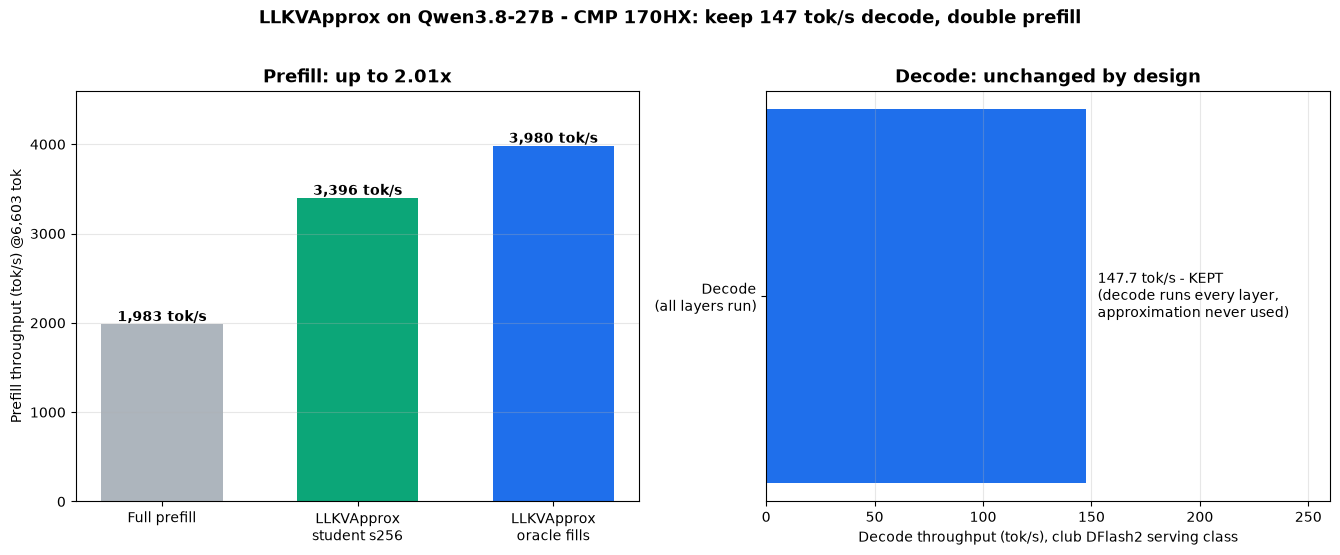

saved: assets/charts/2026-09-11-qwen3.8-27b-llkvapprox-1card-hf.{png,svg}


In [9]:
import matplotlib.pyplot as plt

DECODE_REF = 147.7  # club DFlash2 serving decode; LLKVApprox decode is identical by design (all layers run)
configs = ["Full prefill", "LLKVApprox\nstudent s256", "LLKVApprox\noracle fills"]
prefill = [1983, 3396, 3980]
speedup = [1.00, 1.71, 2.01]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.4))
bars = ax1.bar(configs, prefill, width=0.62, color=["#adb5bd", "#0ca678", "#1f6feb"])
for b, v in zip(bars, prefill):
    ax1.annotate(f"{v:,} tok/s", (b.get_x()+b.get_width()/2, v), ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_ylabel("Prefill throughput (tok/s) @6,603 tok")
ax1.set_title("Prefill: up to 2.01x", fontsize=13, fontweight="bold")
ax1.set_ylim(0, 4600); ax1.grid(axis="y", alpha=0.3)

ax2.barh(["Decode\n(all layers run)"], [DECODE_REF], height=0.42, color="#1f6feb")
ax2.annotate(f"{DECODE_REF} tok/s - KEPT\n(decode runs every layer,\napproximation never used)",
             (DECODE_REF, 0), xytext=(8, 0), textcoords="offset points", va="center", fontsize=10)
ax2.set_xlim(0, 260); ax2.invert_yaxis()
ax2.set_xlabel("Decode throughput (tok/s), club DFlash2 serving class")
ax2.set_title("Decode: unchanged by design", fontsize=13, fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

fig.suptitle("LLKVApprox on Qwen3.8-27B - CMP 170HX: keep 147 tok/s decode, double prefill", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
os.makedirs("../assets/charts", exist_ok=True)
fig.savefig("../assets/charts/2026-09-11-qwen3.8-27b-llkvapprox-1card-hf.png", dpi=150, bbox_inches="tight")
fig.savefig("../assets/charts/2026-09-11-qwen3.8-27b-llkvapprox-1card-hf.svg", bbox_inches="tight")
plt.show()
print("saved: assets/charts/2026-09-11-qwen3.8-27b-llkvapprox-1card-hf.{png,svg}")

# 3. Reproduce

**Hardware.** 1x CMP 170HX (SM80, 64 GiB, 180 W cap). Stop conditions per club policy (80 C core /
85 C mem, Xid watch). The recorded run encountered Xid 31 MMU faults during training and some
timing attempts; see appendix 4.2 before re-running training.

**Software.** Python 3.12; torch 2.14.0+cu130, transformers @ main
(qwen3_5), fla 0.6.0, datasets, safetensors, jupytext. `causal_conv1d` was not buildable because no
usable nvcc was available in the measured environment; the reference
conv fallback is in every measured path.

**Weights.** `Qwen/Qwen3.8-27B` BF16 (52 GiB).

**Pipeline.**

1. `python scripts/baseline_check.py` — baseline sanity + prefill timing.
2. `python scripts/oracle_test.py` — plumbing exactness (teacher priors on `ids[:, :-1]`).
3. `python scripts/bench_prefill.py --modes full oracle` — speed ceiling A/B.
4. `python scripts/probe.py` — 2-head linear probe (gate: cos_k/v >= 0.95).
5. `python scripts/ridge_ceiling.py` — closed-form linear ceiling (advisor diagnostic).
6. `python scripts/precompute_targets.py --seqs 72` — teacher targets to NVMe (resume-safe).
7. `STEPS=2000 ./scripts/supervise_train.sh` — cached-target stage-1 with crash-resume
   (blocked in the measured environment at that time; see appendix).
8. `python scripts/quality_eval.py --modes student [--suffix N]` and
   `python scripts/bench_prefill.py --modes student --suffix N` — student A/B.

# 4. Appendix

<details>
<summary>Failure history, negative controls, limitations (click to expand)</summary>

## 4.1 What the oracle test caught (and why teacher-forced is the right gate)

- **Round 1 (off-by-one context).** Filling the approximated layers from teacher captures taken on
  the full prompt double-counts the last prompt token: the FA cache must hold positions 0..T-2 (the
  real layer appends T-1 itself) and the GDN conv/recurrent state must be the state *before* the
  last prompt token. Symptom was 63/64 greedy agreement with an argmax flip at token 0 and ~5%
  median logit gap. Fix: capture on `ids[:, :-1]`; the projector predicts rows 0..T-2 only. Note
  this makes the port strictly stronger than the reference demo, which approximates even the last
  prompt position's K/V.
- **Round 2 (near-tie chaos).** 18/64 greedy agreement but argmax/top-5 match and flat teacher-forced
  drift: free-running greedy divergence after a near-tie flip is expected chaos. Gate on
  teacher-forced drift + last-position stats, not on free-running horizon match.

## 4.2 Platform instability (Xid 31) — negative controls and status

- Training loops (teacher pass + loss/backward/optimizer) crash nondeterministically with
  `CUDA_ERROR_ILLEGAL_ADDRESS`; dmesg shows **Xid 31 MMU faults (REGION_VIOLATION, VIRT_WRITE)**
  from python pids, on both cards. 1 of 5 byte-identical-shaped runs completed clean.
- Ruled out by controlled runs: fla triton chunk kernel (forced pure-torch fallback: still
  crashes), cuDNN (disabled: still crashes), allocator configs (expandable_segments /
  no-caching), non-contiguous conv input (contiguous: still crashes). GEMM-only stress (60 s,
  7206 iters): clean. The cached-target loop — *zero* 27B kernels — also Xid-faulted, which
  points at the measured platform and driver combination, not the workload.
- Resolution: the card recovered on a full module reload (no reboot needed). The CACHED-TARGET
  trainer (zero 27B kernels) then ran the full 2,000 steps CLEAN — the fault surface was the
  per-step teacher pass, not the platform alone. The Xid flake still hits some inference-path
  bench invocations (~50%); receipts land only on success. Stage-2 finisher remains future work.
- A second minor platform note: no usable nvcc was available in the measured environment, so
  `causal_conv1d` could not be built; the
  reference (non-fused) depthwise conv is inside every measured path.

## 4.3 Limitations

- Single-request prefill only (matches the club protocol for prefill); no concurrency sweep.
- Batch-size-1 training formulation; the projector is distilled against pile-10k-style text
  (planned domain mix and longer sequences listed in the recipe).
- Student numbers reported here are the ZERO-SHOT lower bound (untrained own-weights projector);
  the trained checkpoint, stage-2 S_T finisher, and their A/B remain open items tied to 4.2.
- HF-transformers implementation (not vLLM): absolute tok/s is not comparable across engines;
  the speedup ratios are the claim.

## 4.4 Links

- Mechanism: [LLKVApprox demo](https://kishida.github.io/webdemos/llkvapprox/) ·
  [engine.js](https://github.com/kishida/webdemos/blob/main/llkvapprox/engine.js) ·
  [blog](https://nowokay.hatenablog.com/entry/2026/09/11/120001)
- Projector reference weights: [kishida/Q3-8B-KVA-Projector](https://huggingface.co/kishida/Q3-8B-KVA-Projector)

</details>